In [2]:
!pip install kagglehub

  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.37-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.2-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.37-py3-none-any.whl (262 kB)


In [6]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 10.9 MB/s eta 0:00:0000:0100:01


In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('airbus-ship-detection')

print("Path to competition files:", path)

/home/fakeegor/my_projects/my_ASR_project/tuning_proj/training_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: /home/fakeegor/.cache/kagglehub/competitions/airbus-ship-detection


In [3]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import cv2
from PIL import Image

In [4]:
os.listdir(path)

['train_v2',
 'test_v2',
 'sample_submission_v2.csv',
 'train_ship_segmentations_v2.csv']

In [5]:
sample_submission = pd.read_csv(Path(path) / 'sample_submission_v2.csv')

In [6]:
path_obj = Path(path)
train_segmentations = pd.read_csv(path_obj / "train_ship_segmentations_v2.csv")

In [8]:
axis : {None, int, 2-tuple of ints}, optional.
If axis is an integer, it specifies the axis of x along which to compute the vector norms. If axis is a 2-tuple, it specifies the axes that hold 2-D matrices, and the matrix norms of these matrices are computed. If axis is None then either a vector norm (when x is 1-D) or a matrix norm (when x is 2-D) is returned. The default is None.

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2688534235.py, line 1)

In [111]:
np.arange(10)[-1::-1].reshape(-1, 2)

array([[9, 8],
       [7, 6],
       [5, 4],
       [3, 2],
       [1, 0]])

In [117]:
arr = np.arange(10)[-1::-1].reshape(-1, 2)

arr[-1]+= [2,4]
arr[-2]-=[1,-4]
positions = np.argsort(arr[:, 0])
arr = arr[positions]
arr

array([[2, 6],
       [3, 4],
       [5, 4],
       [7, 6],
       [9, 8]])

In [114]:
arr_1 = np.arange(10)[-1::-1].reshape(-1, 2)
arr_1[-1]+= [2,4]
arr_1[-2]-=[1,-4]
arr_1

array([[9, 8],
       [7, 6],
       [5, 4],
       [2, 6],
       [3, 4]])

In [280]:
#1 - y, 0 - x
def get_num_objects(str_coords):
    coords_span = str_coords.split(" ")
    areas = []
    coords_ = np.array(coords_span[::2]).astype(int)
    #coords_.sort()
    coords = [(int(c)//image.shape[1], int(c)%image.shape[1]) for c in coords_]#coords_span[::2]]
    spans = [int(sp) for sp in coords_span[1::2]]
    coords = np.asarray(coords)
    initial = coords[:]
    
    coord_j = 0

    coords_objs = []
    while len(coords)>0:
        order = np.argsort(coords[:, 0])
        coords = coords[order]
        
        coord_obj = []
        spans_obj = []

        coord_obj.append(coords[0])


        coords_new = []
        spans_new = []

        spans_obj.append(spans[0])
        for i, coord in enumerate( coords[1:]):
            #print(coord_obj)
            if np.linalg.norm(np.array(coord_obj[-1]).reshape(2) - np.array(coord), ord=1, axis=-1)<20 \
                or np.linalg.norm(np.array(coord_obj[-1]).reshape(2)+(0, spans[i]) - (np.array(coord)+(0, spans[i+1])), ord=1, axis=-1)<30:
                coord_obj.append(coord)
                spans_obj.append(spans[i+1])
            else:
                coords_new.append(coord)
                spans_new.append(spans[i+1])

        areas.append(spans_obj)
        coords_objs.append(coord_obj)

        coords = coords_new
        spans = spans_new
        coords = np.asarray(coords)
            
    
    # coords = np.array(coords)

    # norms = np.linalg.norm(coords[1::] - coords[:-1:],ord=2, axis=-1)
    # #print(norms, norms > np.sqrt(2), np.arange(0, norms.shape[0])[norms > np.sqrt(2)])

    # #print(type(norms))
    # if isinstance(norms, np.float64):
    #     norms = np.array([norms])
    # transitions = np.arange(0, norms.shape[0])[norms > 20]+1
    # if transitions.shape[0] == 0:
    #     transitions = np.array([0])
    # objects = [(
    #     coords[ transitions[i-1] if i>0 else 0 : 
    #            transitions[i] if i<transitions.shape[0] else norms.shape[0]
    #         ## create index of distinct shapes
    #     ],
    #     spans[transitions[i-1] if i>0 else 0 : 
    #            transitions[i] if i<transitions.shape[0] else norms.shape[0]
    #     ] 
    #     ) for i in range(transitions.shape[0]+1)]
    
    # for obj in objects:
    #     areas.append(sum(obj[1]))

    return len(coords_objs), coords_objs, areas, initial, [int(sp) for sp in coords_span[1::2]]#norms>20).sum().item()+1, objects#, areas



### GRAPHS OF AREAS OF SHIPS DISTRIBUTIONS

In [281]:
obj = train_segmentations[~train_segmentations.EncodedPixels.isna()].iloc[1]
not_na = train_segmentations[~train_segmentations.EncodedPixels.isna()]
data = not_na.EncodedPixels.apply(get_num_objects)

In [338]:
def color_image(image, coords, areas):
    image_ = image[:].copy()
    for (coord,area) in zip(coords, areas):
        image_[coord[1]:coord[1]+area, coord[0]] = 255
    return image_

In [283]:
num_objs = data.apply(lambda s: s[0])
areas = data.apply(lambda s: s[1+1])

In [294]:
num_objs[num_objs == 3]

188231    3
223465    3
Name: EncodedPixels, dtype: int64

In [285]:
num_objs.value_counts()#, areas

EncodedPixels
1    81427
2      294
3        2
Name: count, dtype: int64

In [355]:
testo = train_segmentations.loc[223465]
image_test = cv2.imread(path_obj / "train_v2" / testo.ImageId)

In [356]:
image = cv2.imread(path_obj / "train_v2" / obj.ImageId)

In [357]:
coords = get_num_objects(obj.EncodedPixels)
coords_test = get_num_objects(testo.EncodedPixels)

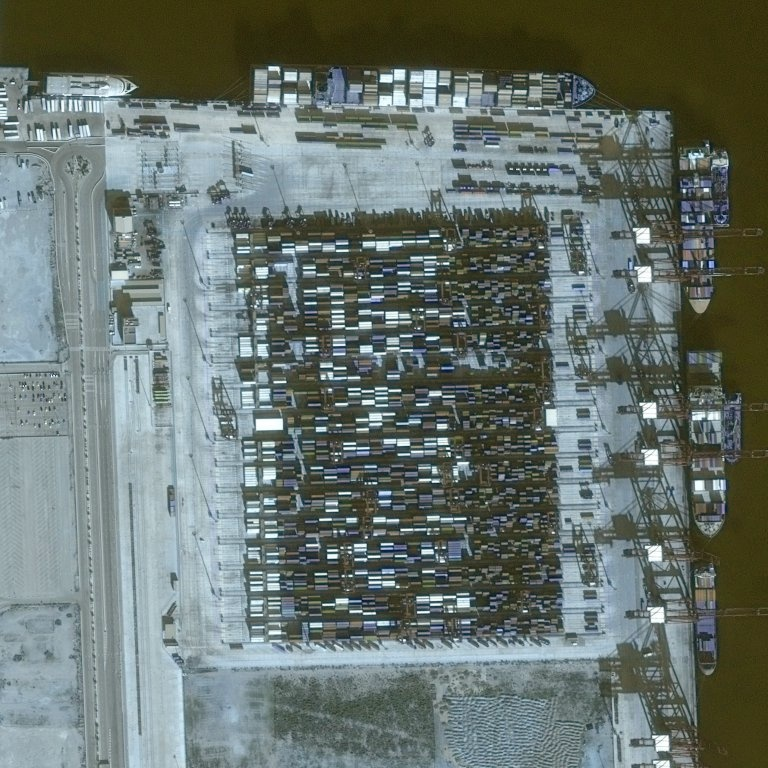

In [358]:
Image.fromarray(image_test)

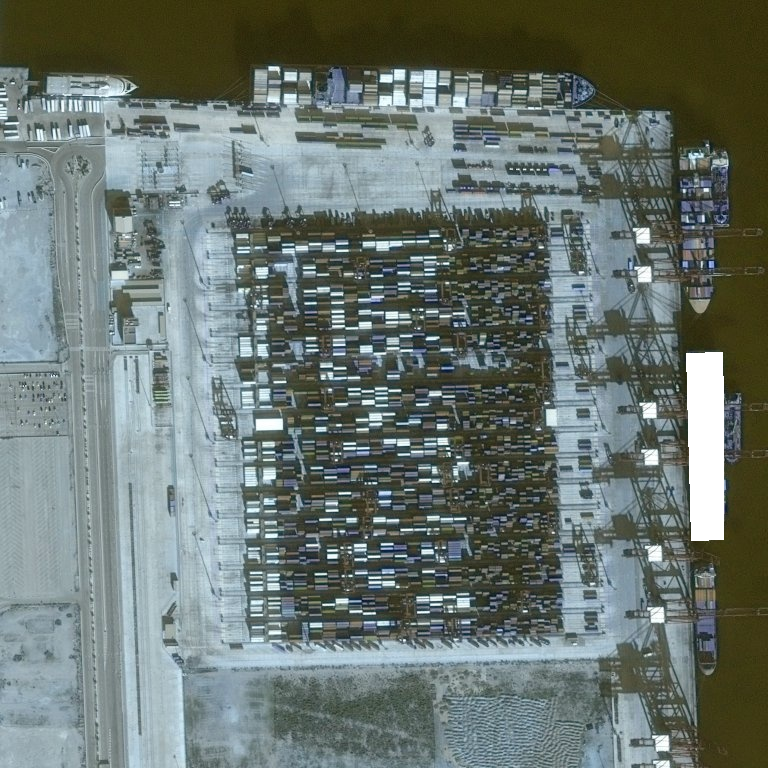

In [359]:
Image.fromarray(color_image(image_test, coords_test[-4][0], coords_test[-3][0]))

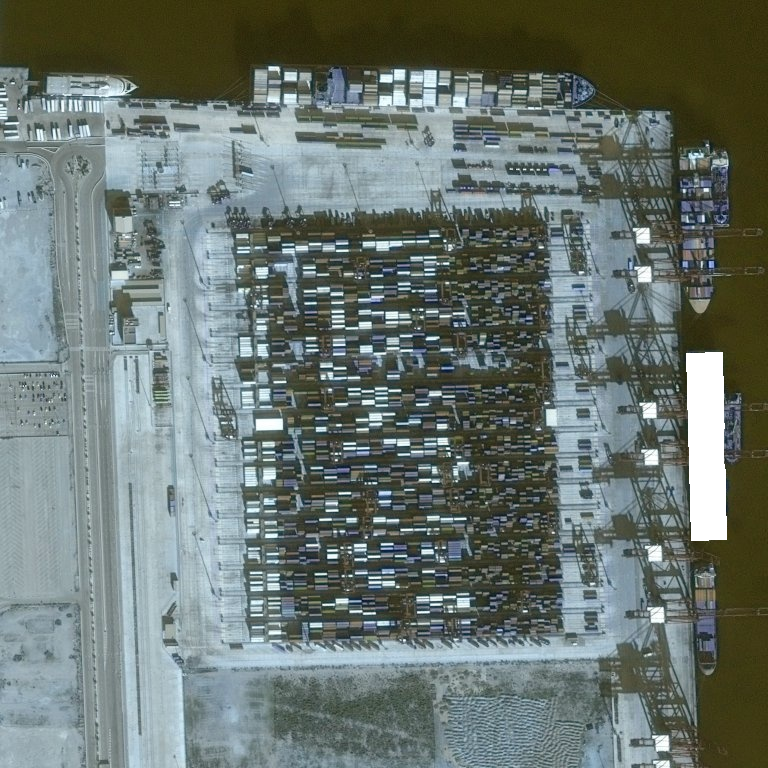

In [360]:
Image.fromarray(color_image(image_test, coords_test[-2], coords_test[-1]))

#### So as we can see, dataset contains only 1 labeled ship for each image

## FOR STABILITY LET US CREATE RECTANGULAR BOUNDING BOXES

In [367]:
def bounding_box(item_):
    coords_ = item_.split(" ")
    #coords_ = np.array(coords_span[::2]).astype(int)
    #coords_.sort()
    item = [(int(c)//image.shape[1], int(c)%image.shape[1]) for c in coords_[::2]]
    spans = [int(sp) for sp in coords_[1::2]]
    item = item + [(item[i][0], item[i][1]+spans[i]) for i in range(len(item))]
    
    item = np.asarray(item)
    y = item[item[:, 1].argmin()].reshape(-1, 2)
    y_min = y[y[:, 0].argmin()]

    x = item[item[:, 0].argmin()].reshape(-1, 2)
    x_min = x[x[:, 1].argmax()]

    x = item[item[:, 1].argmax()].reshape(-1, 2)
    x_max = x[x[:, 0].argmin()]

    y = item[item[:, 0].argmax()].reshape(-1, 2)
    y_max = y[y[:, 1].argmax()]
    return np.array((y_min, x_min, x_max, y_max))




In [368]:

data_bb = not_na.EncodedPixels.apply(bounding_box)

In [405]:
data_bb

2         [[429, 466], [344, 469], [345, 502], [447, 491]]
3         [[473, 288], [469, 294], [487, 308], [491, 302]]
4             [[67, 378], [67, 378], [67, 387], [84, 378]]
5         [[282, 175], [258, 176], [258, 186], [305, 175]]
6             [[72, 387], [72, 387], [72, 388], [78, 387]]
                                ...                       
231694    [[608, 212], [574, 225], [578, 235], [612, 220]]
231709        [[346, 56], [290, 62], [292, 76], [352, 64]]
231712    [[143, 187], [143, 187], [143, 192], [148, 187]]
231713    [[258, 296], [258, 296], [258, 304], [273, 296]]
231714    [[436, 272], [434, 291], [599, 313], [606, 287]]
Name: EncodedPixels, Length: 81723, dtype: object

In [412]:
testo = train_segmentations.loc[231714]
image_test = cv2.imread(path_obj / "train_v2" / testo.ImageId)
testo_bb = data_bb.loc[231714]

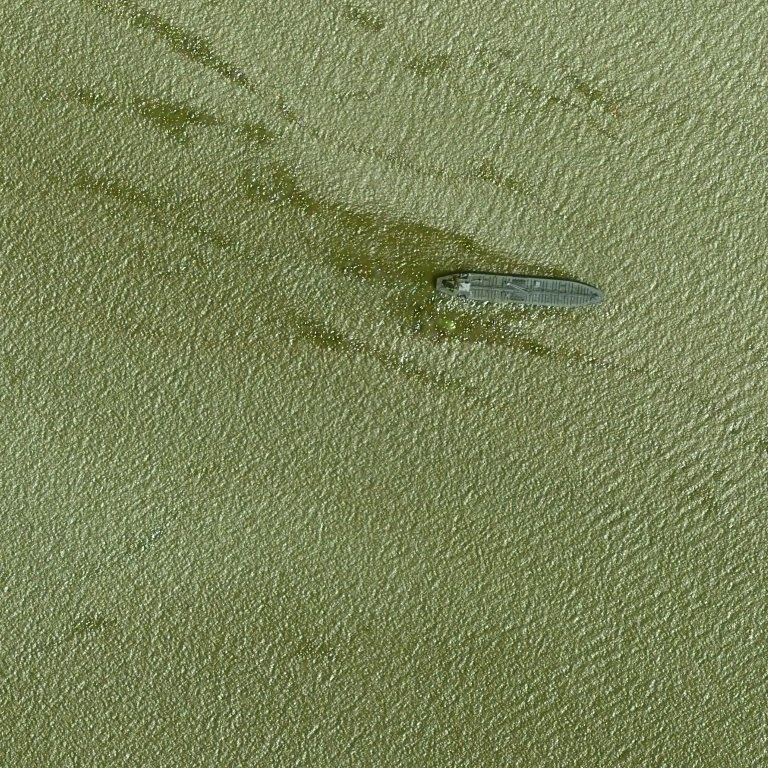

In [413]:
Image.fromarray(image_test)

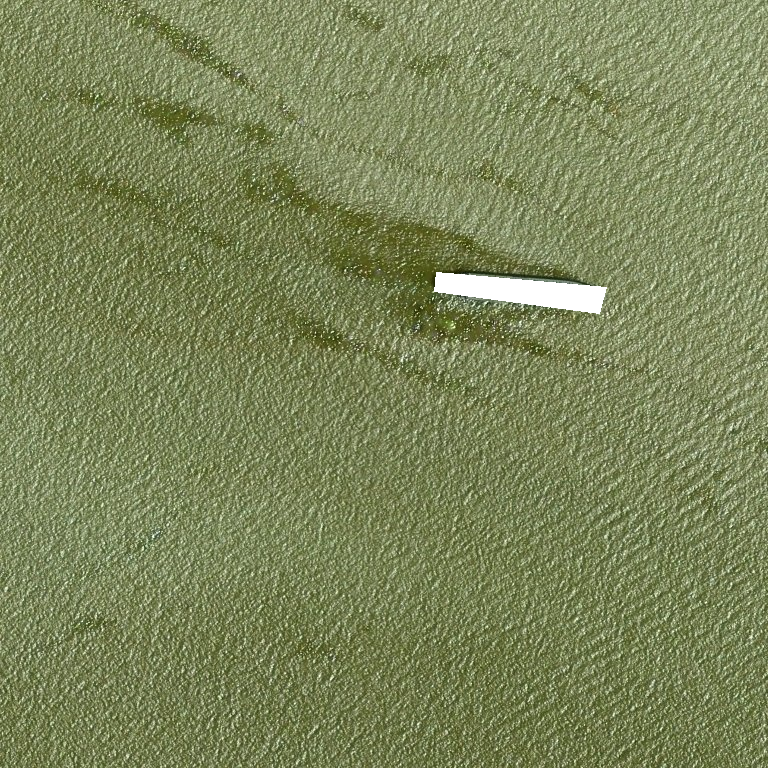

In [416]:
Image.fromarray(color_image_rectangle(image_test, testo_bb))

<PIL.Image.Image image mode=F size=768x768>

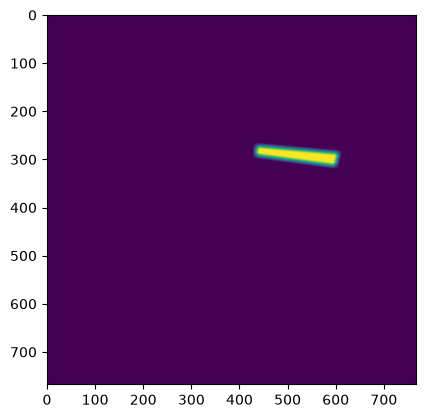

In [498]:
import matplotlib.pyplot as plt
a = create_mask_with_gaussian(image_test, testo_bb)
plt.imshow(a)
Image.fromarray(a)

In [467]:
a

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(768, 768))

In [440]:
data_bb[:20]

2     [[429, 466], [344, 469], [345, 502], [447, 491]]
3     [[473, 288], [469, 294], [487, 308], [491, 302]]
4         [[67, 378], [67, 378], [67, 387], [84, 378]]
5     [[282, 175], [258, 176], [258, 186], [305, 175]]
6         [[72, 387], [72, 387], [72, 388], [78, 387]]
7     [[359, 179], [331, 181], [332, 198], [369, 188]]
9     [[170, 741], [140, 767], [141, 769], [177, 749]]
10    [[161, 733], [131, 753], [137, 763], [167, 742]]
11      [[97, 711], [96, 713], [107, 718], [111, 713]]
12      [[96, 716], [96, 716], [102, 721], [106, 717]]
13    [[196, 662], [195, 663], [198, 666], [200, 663]]
14    [[183, 630], [181, 636], [183, 639], [186, 631]]
15      [[99, 706], [98, 708], [108, 713], [111, 708]]
16    [[113, 709], [112, 711], [116, 714], [120, 711]]
17    [[130, 756], [123, 761], [126, 768], [135, 760]]
18        [[339, 37], [333, 40], [344, 63], [350, 59]]
19        [[330, 42], [324, 46], [336, 68], [344, 63]]
22    [[453, 125], [443, 139], [461, 154], [471, 139]]
24    [[59

In [441]:
def color_image_rectangle(image, coords):
    image_ = image[:].copy()
    
    # coords_ = coords[coords[:, 0].argsort()]
    # coords_ = coords_[coords_[:, 1].argsort()]
    
    image_ = cv2.fillPoly(image_, [coords], color=(255, 255, 255))
    return image_

In [494]:
def create_mask_with_gaussian(image, coords):
    image_ = np.zeros_like(image[:, :, 0]).astype(np.uint8)
    
    # coords_ = coords[coords[:, 0].argsort()]
    # coords_ = coords_[coords_[:, 1].argsort()]
    kernels = np.random.randint(5, 15)*np.ones(2).astype(int)*2+1
    
    image_ = cv2.fillPoly(image_, [coords], color=(255, 255, 255))
    
    image_ = cv2.GaussianBlur(image_.astype(float), ksize=kernels, sigmaX=kernels[0], sigmaY=kernels[1])
    return image_

In [470]:
cv2.?

SyntaxError: invalid syntax (3160562335.py, line 1)

In [303]:
1) min x min y max x, max y 

SyntaxError: unmatched ')' (1582013236.py, line 1)

In [ ]:
train_segmentations.EncodedPixels

,ImageId,EncodedPixels
0,00003e153.jpg,NaN
1,0001124c7.jpg,NaN
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...
...,...,...
231718,fffedbb6b.jpg,NaN
231719,ffff2aa57.jpg,NaN
231720,ffff6e525.jpg,NaN
231721,ffffc50b4.jpg,NaN


In [14]:
sample_submission.head(20)

,ImageId,EncodedPixels
0,00002bd58.jpg,1 2
1,00015efb6.jpg,1 2
2,00023d5fc.jpg,1 2
3,000367c13.jpg,1 2
4,0008ca6e9.jpg,1 2
5,000a4635f.jpg,1 2
6,000bd9dbf.jpg,1 2
7,000f7d875.jpg,1 2
8,0010551d9.jpg,1 2
9,001839c6f.jpg,1 2


In [16]:
sample_submission.EncodedPixels.unique()

<ArrowStringArray>
['1 2']
Length: 1, dtype: str